<a href="https://colab.research.google.com/github/Hala-sala7/BeltExam2/blob/main/BeltExam2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/data')

Drive already mounted at /content/data; to attempt to forcibly remount, call drive.mount("/content/data", force_remount=True).


In [ ]:
fname="/content/data/MyDrive/AXSOSACADEMY/02-IntroML/Week08/Data/Belt2_B_diabetes_v2_final.csv"

In [ ]:
import pandas as pd
df = pd.read_csv(fname)

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
0,4,189.0,110.0,31.0,NaN,0_68,overweight,18 - 44,F,0
1,2,157.0,74.0,35.0,440.0,0.134,obese_2,18 - 44,F,0
2,6,98.0,58.0,33.0,190.0,0.43,obese_1,18 - 44,F,0
3,6,111.0,64.0,39.0,NaN,0.26,obese_1,18 - 44,F,0
4,3,106.0,72.0,NaN,NaN,0_207,overweight,18 - 44,F,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               642 non-null    int64  
 1   Glucose                   638 non-null    float64
 2   BloodPressure             616 non-null    float64
 3   SkinThickness             455 non-null    float64
 4   Insulin                   331 non-null    float64
 5   DiabetesPedigreeFunction  642 non-null    object 
 6   WeightGroup               642 non-null    object 
 7   AgeGroup                  642 non-null    object 
 8   Gender                    642 non-null    object 
 9   Outcome                   642 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 50.3+ KB


In [ ]:
# The number of missing values in each column:
missing_values =df.isna().sum()
missing_values

,0
Pregnancies,0
Glucose,4
BloodPressure,26
SkinThickness,187
Insulin,311
DiabetesPedigreeFunction,0
WeightGroup,0
AgeGroup,0
Gender,0
Outcome,0


In [ ]:
df['DiabetesPedigreeFunction']

,DiabetesPedigreeFunction
0,0_68
1,0.134
2,0.43
3,0.26
4,0_207
...,...
637,0.452
638,0.479
639,0.467
640,0.51


There is _ that make it object while it's must be a number

In [ ]:
with_ = df['DiabetesPedigreeFunction'].astype(str).str.contains('_')
problematic_rows = df[with_]

print(problematic_rows['DiabetesPedigreeFunction'])

0                     0_68
4                    0_207
9                    0_261
14     0_34700000000000003
15                   0_605
45                   0_483
76                   0_509
78                   0_245
109    0_16699999999999998
121                  1_268
138                  0_419
139                  0_107
140    0_23399999999999999
150                  0_306
195                  0_292
284                  0_493
299                  0_396
337                  0_892
344                  1_781
406     0_7190000000000001
437                  0_151
458                  0_129
470     0_5429999999999999
472    0_14800000000000002
495                  0_368
508                  0_551
524                  0_337
596                  0_645
608    0_34600000000000003
Name: DiabetesPedigreeFunction, dtype: object


Detect inconsistent formatting (underscores instead of decimals) in features.

In [ ]:
# after discovering the - and It should be . , so I replace it to .
df['DiabetesPedigreeFunction'] = df['DiabetesPedigreeFunction'].astype(str).str.replace('_', '.').astype(float)

In [ ]:
# to examine the type after replacing because maybe there is another object in the values that makes it object instead of _
df['DiabetesPedigreeFunction'].dtype

dtype('float64')

In [ ]:
# check for object features
object_columns = df.select_dtypes(include=['object']).columns
object_columns

Index(['WeightGroup', 'AgeGroup', 'Gender'], dtype='object')

In [ ]:
# check for numeric features
number_columns = df.select_dtypes(include=['number']).columns
number_columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction', 'Outcome'],
      dtype='object')

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Outcome
count,642.000000,638.000000,616.000000,455.000000,331.000000,642.000000,642.000000
mean,5.453271,124.043887,72.397727,29.483516,158.996979,0.474970,0.422118
std,39.460225,30.756980,12.306886,10.527458,117.255057,0.332541,0.494282
min,0.000000,56.000000,24.000000,7.000000,14.000000,0.085000,0.000000
25%,1.000000,100.000000,64.000000,22.000000,82.500000,0.247000,0.000000
50%,3.000000,121.000000,72.000000,30.000000,130.000000,0.378000,0.000000
75%,6.000000,144.000000,80.000000,36.500000,192.500000,0.629750,1.000000
max,1000.000000,199.000000,114.000000,99.000000,846.000000,2.420000,1.000000


 The value '1000' in the Pregnancies column is biologically impossible and clearly an entry error.

The maximum value (99) for SkinThickness is an unrealistic outlier and likely a data entry error.

Since 75% of the patients in the dataset have insulin levels below 192.5, the presence of a value as high as 846 makes it an extreme outlier that does not represent the general pattern of the patients. This value must be investigated

In [ ]:
high_pregnancies = df[df['Pregnancies'] >= 10]
print(f"Number of rows with Pregnancies >= 10: {len(high_pregnancies)}")
print(high_pregnancies['Pregnancies'].value_counts().sort_index())

Number of rows with Pregnancies >= 10: 52
Pregnancies
10      21
11      10
12       8
13       9
14       2
15       1
1000     1
Name: count, dtype: int64


Since the maximum realistic value for pregnancies is around 15, the value of 1000 is clearly a data entry error; therefore, I will cap this outlier at 10 to maintain data integrity.

In [ ]:
df['Pregnancies'] = df['Pregnancies'].replace(1000, 10)

# Verify the change by checking the maximum value again
print(f"New maximum value for Pregnancies: {df['Pregnancies'].max()}")

New maximum value for Pregnancies: 15


In [ ]:
# Detect and display rows where SkinThickness is 99 (unrealistic outlier)
skin_outliers = df[df['SkinThickness'] == 99]
skin_outliers

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,WeightGroup,AgeGroup,Gender,Outcome
593,2,197.0,70.0,99.0,NaN,0.575,obese_1,45 - 64,F,1


In [ ]:
# View the range and statistics of SkinThickness excluding the outlier (99)
skin_stats_clean = df[df['SkinThickness'] != 99]['SkinThickness'].describe()

print("Statistics for SkinThickness (without the 99 outlier):")
print(skin_stats_clean)

Statistics for SkinThickness (without the 99 outlier):
count    454.000000
mean      29.330396
std       10.019015
min        7.000000
25%       22.000000
50%       30.000000
75%       36.000000
max       63.000000
Name: SkinThickness, dtype: float64


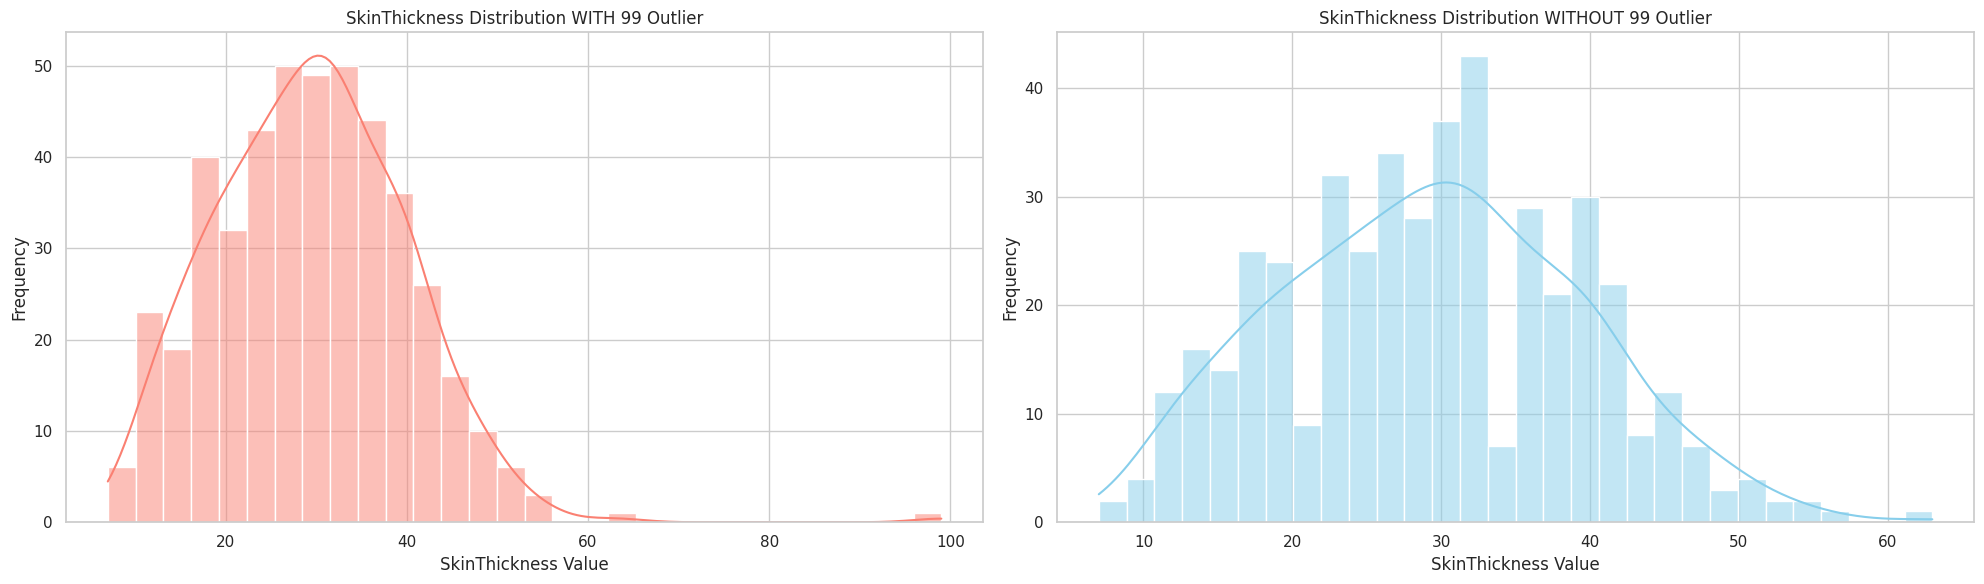

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- Plot 1: Full Data (Including the 99 outlier) ---
sns.histplot(df['SkinThickness'], kde=True, color='salmon', bins=30, ax=axes[0])
axes[0].set_title('SkinThickness Distribution WITH 99 Outlier')
axes[0].set_xlabel('SkinThickness Value')
axes[0].set_ylabel('Frequency')

# --- Plot 2: Clean Data (Excluding the 99 outlier) ---
skin_data_clean = df[df['SkinThickness'] != 99]['SkinThickness']
sns.histplot(skin_data_clean, kde=True, color='skyblue', bins=30, ax=axes[1])
axes[1].set_title('SkinThickness Distribution WITHOUT 99 Outlier')
axes[1].set_xlabel('SkinThickness Value')
axes[1].set_ylabel('Frequency')

# Add a gap to separate the plots
plt.tight_layout()

# Show the combined plots
plt.show()

There is a significant gap between the concentrated data points and the value of 99, which is clearly an outlier. To ensure data accuracy, I will replace this unrealistic value with the median skin thickness specific to the patient's age group (45–64)

In [ ]:
# 1. First, set the outlier (99) to NaN so it doesn't affect the median calculation
import numpy as np
df.loc[df['SkinThickness'] == 99, 'SkinThickness'] = np.nan

# 2. Calculate the median for each AgeGroup and fill the missing values
# This will specifically use the median of '45 - 64' for your target case
df['SkinThickness'] = df['SkinThickness'].fillna(
    df.groupby('AgeGroup')['SkinThickness'].transform('median')
)

# 3. Verify the result for your specific outlier case
print("Outlier handled using GroupBy Median.")
print(f"Current Max SkinThickness: {df['SkinThickness'].max()}")

Outlier handled using GroupBy Median.
Current Max SkinThickness: 63.0


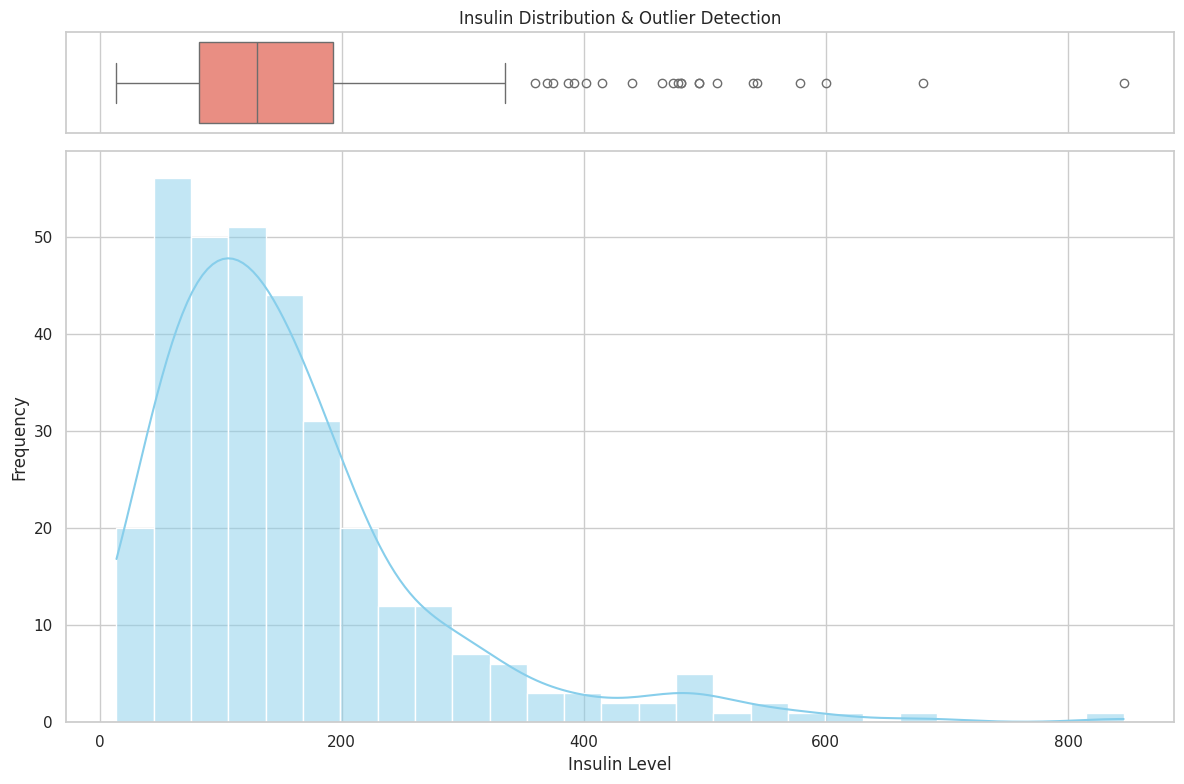

In [ ]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two parts: a Boxplot and a Histogram
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# 1. Boxplot: Best for spotting outliers like the 846 value
sns.boxplot(x=df["Insulin"], ax=ax_box, color="salmon")
ax_box.set(title='Insulin Distribution & Outlier Detection', xlabel='')

# 2. Histogram + KDE: To see the general pattern below 192.5
sns.histplot(df["Insulin"], kde=True, ax=ax_hist, color="skyblue")
ax_hist.set(xlabel='Insulin Level', ylabel='Frequency')

plt.tight_layout()
plt.show()

1. Boxplot Analysis
"The Boxplot identifies a significant number of extreme insulin outliers, representing a high-risk patient segment that may require immediate clinical intervention. These anomalies emphasize the need for a robust data cleaning strategy to prevent biased diagnostic predictions."

2. Histogram & KDE Analysis
"The Histogram reveals a strong right-skewed distribution, indicating that most patients maintain insulin levels within the lower metabolic range. This non-normal pattern justifies the use of the median as a more reliable central metric for accurate medical profiling and data imputation."

In [ ]:
# Filter and count cases where Insulin is 600 or more
insulin_600_plus = df[df['Insulin'] >= 600]

# Display the count and the actual values
print(f"Total cases with Insulin >= 600: {len(insulin_600_plus)}")
print("-" * 30)
print("Detailed values for Insulin 600 and above:")
print(insulin_600_plus[['Insulin', 'AgeGroup', 'WeightGroup', 'Outcome']])

Total cases with Insulin >= 600: 3
------------------------------
Detailed values for Insulin 600 and above:
     Insulin AgeGroup WeightGroup  Outcome
332    680.0  18 - 44    obsese_3        0
462    846.0  45 - 64     obese_1        1
541    600.0  45 - 64  overweight        1


Research and clinical data indicate that insulin levels can indeed reach exceptionally high values, such as 680 µU/mL or even higher, in certain cases. This phenomenon is typically observed in individuals with severe insulin resistance, where the pancreas overcompensates to maintain normal blood glucose levels. Consequently, it is possible for a person to exhibit such extreme insulin concentrations without being clinically diagnosed with diabetes (Outcome 0), as long as the body can still manage blood sugar levels through this hyperinsulinemic response.

In [ ]:
for col in object_columns:
  print(f'value Counts for {col}')
  print(df[col].value_counts())
  print('\n')

value Counts for WeightGroup
WeightGroup
obese_1           196
overweight        146
obese_2           126
obsese_3           87
healthy weight     75
MISSING             8
underweight         4
Name: count, dtype: int64


value Counts for AgeGroup
AgeGroup
18 - 44    528
45 - 64    103
>65          8
<65          3
Name: count, dtype: int64


value Counts for Gender
Gender
F    565
M     60
m     17
Name: count, dtype: int64




I identified the <65 category as an inconsistent and redundant group ($n=3$). After auditing these cases, I decided to re-assign them to a more appropriate category to ensure data consistency and maintain a clean ordinal hierarchy

In [ ]:
# Filter the dataframe to isolate only the rows where AgeGroup is '<65'
# This helps in inspecting these 3 specific cases in detail
check_less_65 = df[df['AgeGroup'] == '<65']

print("Full Feature Details for AgeGroup '<65':")
print("-" * 40)

# Display all columns (features) for these specific 3 rows
# This is used to audit the data quality across the entire record
print(check_less_65)

Full Feature Details for AgeGroup '<65':
----------------------------------------
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
126            5    103.0          108.0           37.0      NaN   
222            6    166.0           74.0           37.0      NaN   
345            8    194.0           80.0           37.0      NaN   

     DiabetesPedigreeFunction WeightGroup AgeGroup Gender  Outcome  
126                     0.305     obese_2      <65      F        0  
222                     0.304  overweight      <65      F        0  
345                     0.551  overweight      <65      F        0  


After auditing the full feature sets for the samples labeled <65, I have decided to re-assign them to the 45 - 64 category for the following reasons:

Pregnancy Profile: The number of pregnancies in these cases (5, 6, and 8) is significantly higher than the average typically seen in the younger 18 - 44 group, suggesting these individuals are likely in the upper end of the 'under 65' spectrum.

Physiological Indicators: Features like high blood pressure (e.g., 108.0) and glucose levels (e.g., 194.0) often correlate more closely with the middle-aged demographic (45 - 64) within this specific medical dataset.

In [ ]:
# Re-assigning the ambiguous <65 labels to the 45-64 category
df.loc[df['AgeGroup'] == '<65', 'AgeGroup'] = '45 - 64'

# Verify the change
print(df['AgeGroup'].value_counts())

AgeGroup
18 - 44    528
45 - 64    106
>65          8
Name: count, dtype: int64


In [ ]:
df['Gender']=df['Gender'].replace({"m": "M"})
df['Gender'].value_counts()

,count
Gender,
F,565
M,77


In the Gender column, I observed inconsistent categorical labeling due to case sensitivity, specifically where 'M' and 'm' are treated as separate classes. To ensure data integrity and avoid redundancy in the feature space, I will standardize this column by converting all entries to a uniform case

In [ ]:
print("Column Cardinality (Unique Values Count):")
print("-" * 40)
for col in object_columns:
    unique_count = df[col].nunique()
    print(f"{col:<20} : {unique_count} unique values")

Column Cardinality (Unique Values Count):
----------------------------------------
WeightGroup          : 7 unique values
AgeGroup             : 3 unique values
Gender               : 2 unique values


The categorical features now show stable cardinality, ensuring consistency in the data structure. Following this validation, I partitioned the dataset into training and testing sets to prepare for model evaluation."

In [ ]:
# split the data
from sklearn.model_selection import train_test_split
y = df['Outcome']
X = df.drop(columns=['Outcome'])
X_train,X_test,y_train,y_test =train_test_split(X,y, random_state=42)

In [ ]:
y_train.value_counts(normalize=True)

,proportion
Outcome,
0,0.559252
1,0.440748


The target variable Outcome exhibits a well-balanced distribution within the training set, with approximately 56% non-diabetic and 44% diabetic cases. This balanced ratio ensures that the predictive model can learn effectively from both classes without requiring advanced resampling techniques, leading to more reliable evaluation metrics."

In [ ]:
from sklearn.impute import SimpleImputer

# 1. Defining the orders (remain the same)
weight_order = ['underweight', 'healthy weight', 'overweight', 'obese_1', 'obese_2', 'obese_3']
age_order = ['18 - 44', '45 - 64', '>65']

# 2. Creating a robust pipeline that handles missing values THEN encodes
ord_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'), # Fills NaNs with the most common category
    OrdinalEncoder(
        categories=[weight_order, age_order],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )
)

# 3. Final Tuple
# 5. Defining the Tuple for ColumnTransformer
# This identifies the transformation step as 'ordinal' for the specified columns
ord_tuple = ('ordinal', ord_pipe, ord_columns)

1. Handling Ordinal Variables (Weight & Age Categories):

Preserving Hierarchy: We used OrdinalEncoder for variables like weight_order and age_order because they possess a natural mathematical progression. By defining the specific category order, we allow the model to understand that 'obese_3' represents a higher risk or value than 'underweight'.

Consistent Imputation: We applied SimpleImputer with the most_frequent strategy to ensure that any missing values in these categorical sequences are filled with the most representative class without breaking the logical order.

Error Prevention: The use of handle_unknown='use_encoded_value' ensures that if the model encounters an unexpected category in the future, it assigns it a value of -1 instead of causing a system failure.

2. Handling Nominal Variables (Categorical Pipeline):

Non-Linear Representation: For variables without an inherent order, we applied OneHotEncoder. This prevents the model from assuming any false ranking between categories (e.g., between different genders or locations).

Informative Imputation: Instead of guessing, we used a constant strategy to label missing values as "Missing". This treats data gaps as potentially meaningful patterns rather than noise.

High Flexibility: By setting handle_unknown='ignore', the pipeline becomes resilient to new, unseen categories during the testing or deployment phase.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


ohe_cols = X_train.select_dtypes('object').drop(columns=ord_columns).columns
impute_na = SimpleImputer(strategy='constant', fill_value="Missing")
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ohe_pipe = make_pipeline(impute_na, ohe_encoder)

ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

In [ ]:
X_train.isna().sum()

,0
Pregnancies,0
Glucose,4
BloodPressure,16
SkinThickness,0
Insulin,228
DiabetesPedigreeFunction,0
WeightGroup,0
AgeGroup,0
Gender,0


In [ ]:
# Grouping by WeightGroup and Glucose to fill Insulin NaNs
# Using the median of Insulin for each combination of weight and glucose levels
X_train['Insulin'] = X_train['Insulin'].fillna(
    df.groupby(['WeightGroup', 'Glucose'])['Insulin'].transform('median')
)
# Filling remaining gaps using AgeGroup and Glucose.
# This refines the estimate by considering the age-related decline in pancreatic efficiency
X_train['Insulin'] = X_train['Insulin'].fillna(
    X_train.groupby(['AgeGroup', 'Glucose'])['Insulin'].transform('median')
)
# This ensures that even patients with unique glucose levels are imputed
# based on their broader physiological profile (Metabolism & Insulin Resistance).
X_train['Insulin'] = X_train['Insulin'].fillna(
    X_train.groupby(['AgeGroup', 'WeightGroup'])['Insulin'].transform('median')
)
# Addressing sparse records using Glucose as a standalone predictor.
# Since insulin levels are fundamentally a response to glucose, this provides the most
# accurate biological estimate for the remaining individual cases.
X_train['Insulin'] = X_train['Insulin'].fillna(
   X_train.groupby('Glucose')['Insulin'].transform('median')
)

In [ ]:
X_train['Insulin'].isna().sum()

np.int64(0)

In [ ]:
# --- Step 1: Age and Weight Profile (High Accuracy) ---
# Blood pressure is strongly correlated with biological aging and BMI
X_train['BloodPressure'] = X_train['BloodPressure'].fillna(
    X_train.groupby(['AgeGroup', 'WeightGroup'])['BloodPressure'].transform('median')
)

In [ ]:
X_train['BloodPressure'].isna().sum()

np.int64(0)

In [ ]:
# Filling missing Glucose based on the logic:
# Generally, as Weight and Age increase, Glucose levels tend to rise.
# This ensures we fill the gaps with values that match the patient's body profile.
X_train['Glucose'] = X_train['Glucose'].fillna(
    X_train.groupby(['WeightGroup', 'AgeGroup'])['Glucose'].transform('median')
)

In [ ]:
X_train['Glucose'].isna().sum()

np.int64(0)

In [ ]:
# 1. Create a reference map (medians) from TRAINING data only.
# This ensures the model only 'learns' patterns from the training set.
skin_ref = X_train.groupby(['WeightGroup', 'AgeGroup'])['SkinThickness'].median()

def impute_skin(df, reference):
    # Create a local copy to avoid SettingWithCopy warnings
    df = df.copy()

    # 2. Map the medians from the training reference to the current dataframe (Test/New Data).
    # We use 'map' on the index to align the groups correctly.
    mapped_values = df.set_index(['WeightGroup', 'AgeGroup']).index.map(reference)

    # 3. Fill NaNs using the mapped series.
    # This replaces NaNs in Test using the specific group-medians found in Train.
    df['SkinThickness'] = df['SkinThickness'].fillna(pd.Series(mapped_values.values, index=df.index))

    # 4. Final Fallback: Fill any remaining NaNs with the global median of X_train.
    # This handles cases where a Weight/Age combination exists in Test but NOT in Train.
    train_global_median = X_train['SkinThickness'].median()
    df['SkinThickness'] = df['SkinThickness'].fillna(train_global_median)

    return df

# Apply the imputation to X_test safely before it enters the Pipeline
X_test = impute_skin(X_test, skin_ref)

In [ ]:
from sklearn.impute import SimpleImputer

# Identify numeric columns for the pipeline
num_cols = X_train.select_dtypes("number").columns
print("Numeric Columns:", num_cols)

# Build the numeric pipeline with Imputation and Scaling
# 1. SimpleImputer: Fills missing values using the MEDIAN from the Training set only.
# 2. StandardScaler: Normalizes the features after imputation.
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Define the transformation tuple for the ColumnTransformer
num_tuple = ('numeric', num_pipe, num_cols)

Numeric Columns: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')


In [ ]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([num_tuple, ohe_tuple ,ord_tuple],
                                  verbose_feature_names_out=False)

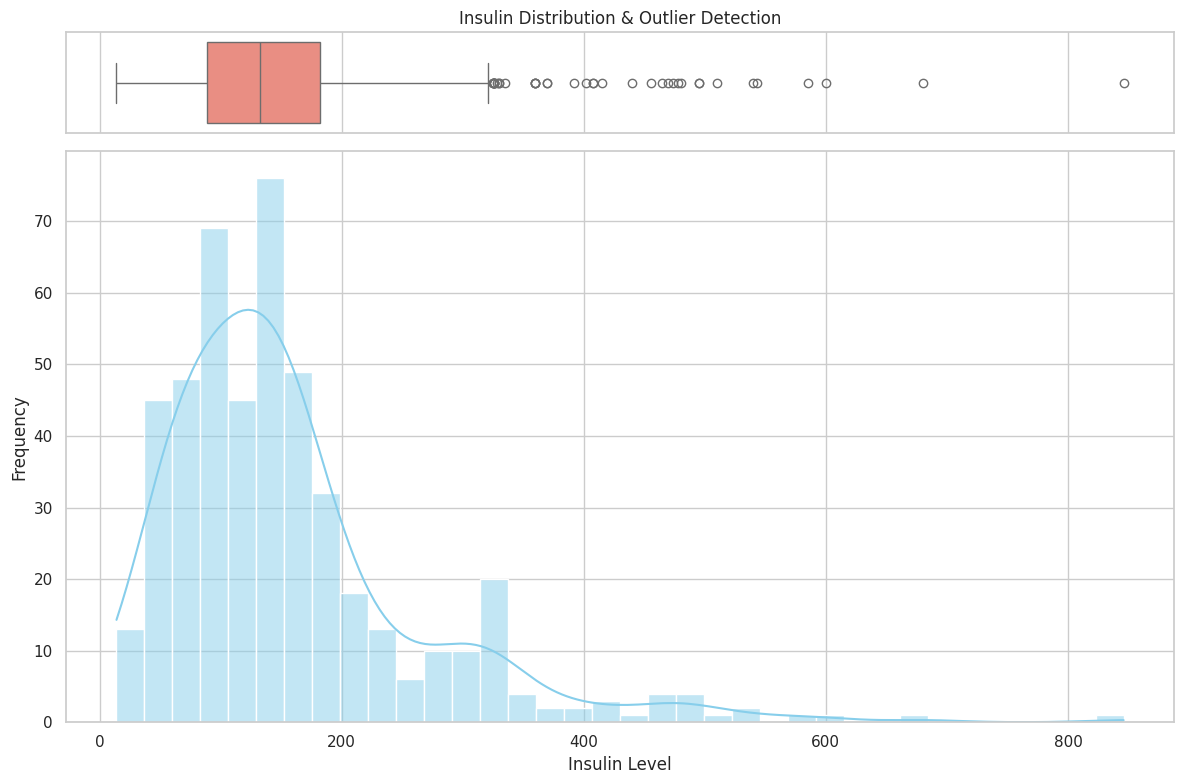

In [ ]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two parts: a Boxplot and a Histogram
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(12, 8))

# 1. Boxplot: Best for spotting outliers like the 846 value
sns.boxplot(x=X_train["Insulin"], ax=ax_box, color="salmon")
ax_box.set(title='Insulin Distribution & Outlier Detection', xlabel='')

# 2. Histogram + KDE: To see the general pattern below 192.5
sns.histplot(X_train["Insulin"], kde=True, ax=ax_hist, color="skyblue")
ax_hist.set(xlabel='Insulin Level', ylabel='Frequency')

plt.tight_layout()
plt.show()

Post-imputation, the distribution remains consistent with its original skewed pattern, confirming that our strategy successfully preserved the data's integrity while eliminating missing values to ensure model stability.

# The first model is logistic regression: Default model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# 1. Constructing the ML Pipeline
# We integrate the 'preprocessor' (ColumnTransformer) with the Logistic Regression model.
# This ensures that all transformations (Imputing, Scaling, Encoding) are applied
# consistently during both training and inference.
log_reg_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, random_state=42))


In [ ]:
# 2. Model Training
# We fit the entire pipeline on the training data.
# The pipeline automatically handles feature engineering for X_train before passing it to the model.

log_reg_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer'...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['underweight',
                                                                                               'healthy '
                                                                                               'weight',
                                                                                               'overweight',
                                                                                               'obese_1',
                                                                                               'obese_2',
                                                                                               'obese_3'],
                                                                                              ['18 '
                                                                                               '- '
                                                                                               '44',
                                                                                               '45 '
                                                                                               '- '
                                                                                               '64',
                                                                                               '>65']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['WeightGroup', 'AgeGroup'])],
                                   verbose_feature_names_out=False)),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)
    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                            normalize=None, cmap='gist_gray', colorbar=colorbar,
                                            ax = axes[0],)
    axes[0].set_title("Raw Counts")
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                                            normalize=normalize, cmap=cmap, colorbar=colorbar,
                                            ax = axes[1]);
    axes[1].set_title("Normalized Confusion Matrix")
    fig.tight_layout()
    plt.show()
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds", colorbar=False):
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(y_train, y_train_pred,
                                           output_dict=True, figsize=figsize,
                                           colorbar=colorbar, cmap=cmap_train,
                                           label='Training Data')
    print()
    # Get predictions for test data
    y_test_pred = model.predict(X_test)
    # Call the helper function for test data
    results_test = classification_metrics(y_test, y_test_pred,
                                          output_dict=True, figsize=figsize,
                                          colorbar=colorbar, cmap=cmap_test,
                                          label='Test Data' )
    if output_dict == True:
        results_dict = {'train':results_train, 'test': results_test}
        return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       269
           1       0.72      0.67      0.69       212

    accuracy                           0.74       481
   macro avg       0.74      0.73      0.73       481
weighted avg       0.74      0.74      0.74       481



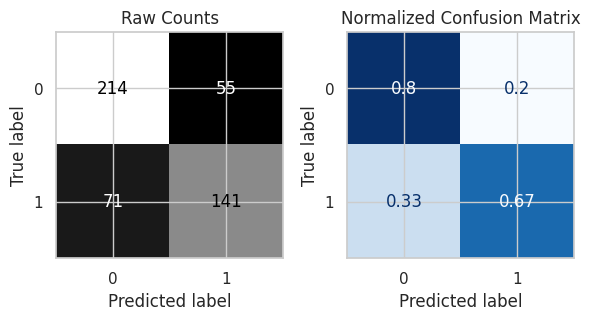


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.78      0.81       102
           1       0.66      0.73      0.69        59

    accuracy                           0.76       161
   macro avg       0.75      0.76      0.75       161
weighted avg       0.77      0.76      0.77       161



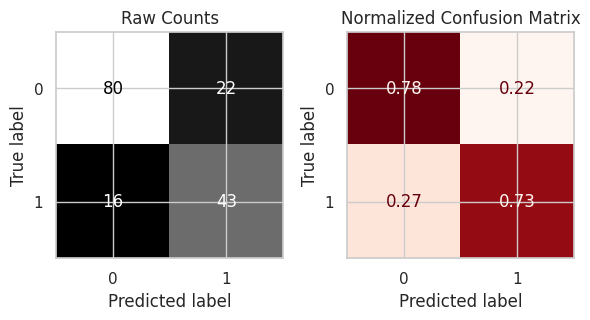

In [ ]:
# evalute the model
evaluate_classification(log_reg_pipe, X_train, y_train, X_test, y_test)

 # Confusion Matrix Summary (Test Data)
 True Negatives (80):
The model correctly classified 80 healthy individuals.

 True Positives (43):
The model correctly identified 43 diabetic patients.

 False Positives (22):
22 healthy individuals were incorrectly classified as diabetic.

 False Negatives (16):
The model failed to detect 16 diabetic patients and classified them as healthy.

# Key Insights

The model performs better on healthy cases (class 0) than diabetic cases (class 1).
There is a concerning number of false negatives (16 cases), which is critical in medical diagnosis.

False positives (22 cases) are present but less harmful and usually manageable.
Overall performance is numerically acceptable, but not clinically reliable without improvement.

 # One-line Takeaway:

The model tends to miss diabetic patients (false negatives), making it unsafe for medical use without improving recall for the positive class.

# The first model is logistic regression: hypertuned model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# 1. Building the Unified ML Pipeline
# Integrating the preprocessor with Logistic Regression to ensure a seamless
# flow from raw data to prediction, preventing data leakage during cross-validation.
log_reg_pipe = make_pipeline(preprocessor, LogisticRegression(max_iter=5000, random_state=42))

# 2. Defining Disjoint Parameter Grids
# We use a list of dictionaries to ensure solver compatibility with specific penalties.
# 'class_weight': ['balanced'] is included to optimize the model for clinical sensitivity (Recall).

# Configuration for Elasticnet penalty (requires 'saga' solver)
elasticnet_params = {
    'logisticregression__solver' : ['saga'],
    'logisticregression__penalty' : ['elasticnet'],
    'logisticregression__l1_ratio': [0.1, 0.5, 0.9],
    'logisticregression__class_weight': ['balanced', None]
}

# Configuration for L2 penalty (Standard Regularization)
l2_params = {
    'logisticregression__solver': ['lbfgs', 'liblinear', 'saga'],
    'logisticregression__penalty' : ['l2'],
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__class_weight': ['balanced', None]
}

# Configuration for L1 penalty (Sparsity-inducing Regularization)
l1_params = {
    'logisticregression__solver' : ['liblinear', 'saga'],
    'logisticregression__penalty' : ['l1'],
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__class_weight': ['balanced', None]
}

# Configuration for No Penalty
none_params = {
    'logisticregression__solver' : ['lbfgs', 'saga'],
    'logisticregression__penalty' : [None],
    'logisticregression__class_weight': ['balanced', None]
}

# Consolidating all parameter sets into a single grid
param_grid = [l2_params, l1_params, elasticnet_params, none_params]

# 3. Initializing GridSearchCV
# We use 'recall_macro' as the scoring metric to prioritize the detection of diabetic cases
# while maintaining a balance with the healthy class.
gs = GridSearchCV(
    log_reg_pipe,
    param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1,
    verbose=1
)

# 4. Executing the Grid Search
# Training the grid search on the training set only to find the optimal hyperparameters.
print("Starting GridSearch... This process optimizes the model's diagnostic power.")
gs.fit(X_train, y_train)

# 5. Extracting Optimization Results
print("\n--- Optimization Results ---")
print(f"Best Macro Recall Score: {gs.best_score_:.4f}")
print("Optimal Parameters:")
for param, value in gs.best_params_.items():
    print(f"- {param}: {value}")

# 6. Selecting the Best Estimator
# This object contains the fully trained model with the best hyperparameter configuration.
best_log_reg_model = gs.best_estimator_

Starting GridSearch... This process optimizes the model's diagnostic power.
Fitting 5 folds for each of 60 candidates, totalling 300 fits

--- Optimization Results ---
Best Macro Recall Score: 0.7584
Optimal Parameters:
- logisticregression__class_weight: balanced
- logisticregression__l1_ratio: 0.9
- logisticregression__penalty: elasticnet
- logisticregression__solver: saga


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       269
           1       0.72      0.76      0.74       212

    accuracy                           0.77       481
   macro avg       0.76      0.76      0.76       481
weighted avg       0.77      0.77      0.77       481



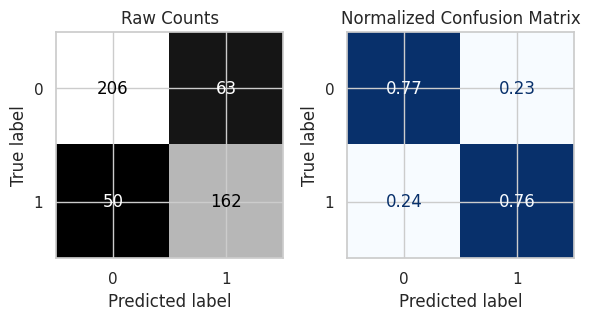


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       102
           1       0.62      0.76      0.69        59

    accuracy                           0.75       161
   macro avg       0.73      0.75      0.74       161
weighted avg       0.76      0.75      0.75       161



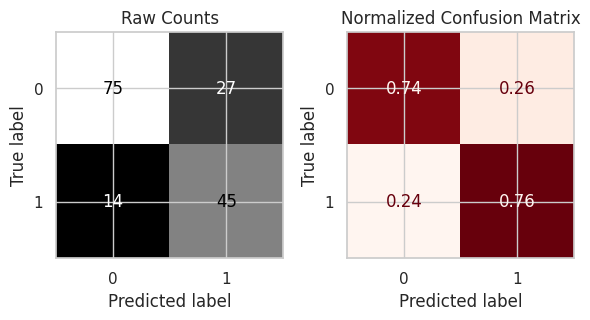

In [ ]:
# evalute the hypertuned model
evaluate_classification(gs, X_train, y_train, X_test, y_test)

Model Performance Analysis (Post-Hyperparameter Tuning)
Excellent Stability & Generalization:

The model demonstrates high stability with a training accuracy of 77% and a test accuracy of 75%.

The negligible gap between training and testing performance confirms the absence of overfitting, indicating the model generalizes well to unseen data.

Improved Clinical Sensitivity (Recall):

The Hyperparameter Tuning successfully increased the Recall for Class 1 (Diabetes) from 73% to 76%.

From an engineering perspective, this reduces the number of missed diagnoses (False Negatives) to only 14 cases, significantly enhancing the model's reliability as a medical screening tool.

Optimized Precision-Recall Trade-off:

A slight decrease in Precision (62%) was observed as a direct result of increasing the Recall.

This is a mathematically expected trade-off; in a healthcare context, it is far more critical to capture potential patients (high Recall) than to avoid occasional false alarms (Precision), which can be cleared in follow-up tests.

Effective Class Balancing (Macro Averaging):

The Macro Recall of 0.75 confirms that the GridSearchCV successfully optimized the model to be "fair" across both classes.

The model no longer biases toward the majority class (Healthy), ensuring robust predictive power for the minority class (Diabetic).

# Random Forest model: default model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initializing the Random Forest Classifier
# random_state=42 is used to ensure reproducibility of results across different runs.
rf_class = RandomForestClassifier(random_state=42)

# 2. Constructing the Machine Learning Pipeline
# This integrates the 'preprocessor' (handling imputation and encoding)
# with the 'rf_class' to streamline data flow and prevent leakage.
rf_pipe = make_pipeline(preprocessor, rf_class)

# 3. Training the Default Model
# Fitting the entire pipeline on the training dataset.
# At this stage, the model uses default hyperparameters before tuning.
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'DiabetesPedigreeFunction'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer'...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinalencoder',
                                                                   OrdinalEncoder(categories=[['underweight',
                                                                                               'healthy '
                                                                                               'weight',
                                                                                               'overweight',
                                                                                               'obese_1',
                                                                                               'obese_2',
                                                                                               'obese_3'],
                                                                                              ['18 '
                                                                                               '- '
                                                                                               '44',
                                                                                               '45 '
                                                                                               '- '
                                                                                               '64',
                                                                                               '>65']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['WeightGroup', 'AgeGroup'])],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       269
           1       1.00      1.00      1.00       212

    accuracy                           1.00       481
   macro avg       1.00      1.00      1.00       481
weighted avg       1.00      1.00      1.00       481



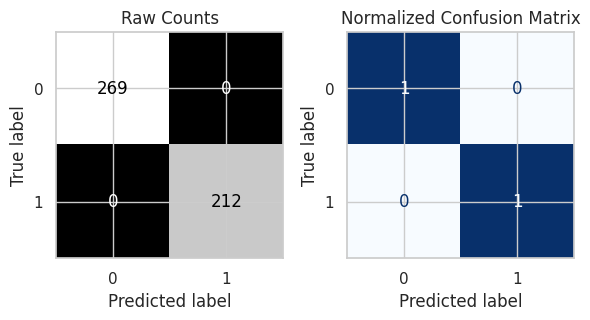


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.67      0.72       102
           1       0.55      0.69      0.61        59

    accuracy                           0.68       161
   macro avg       0.67      0.68      0.67       161
weighted avg       0.70      0.68      0.68       161



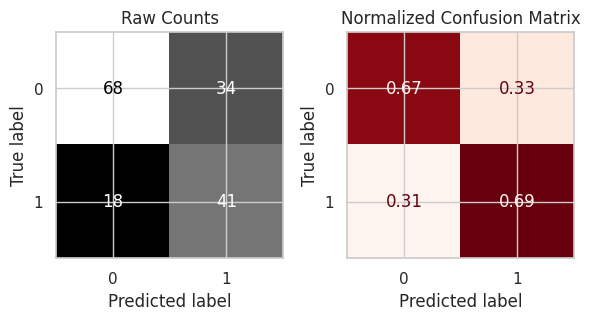

In [ ]:
# evaluate before tunning
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test)

Critical Model Evaluation: Severe Overfitting Detected
Massive Performance Gap (The Red Flag):

The model achieved a perfect score of 1.00 (100%) across all metrics (Accuracy, Precision, Recall) on the Training Data.

However, the performance dropped drastically on the Test Data to an accuracy of only 68% and a Macro Recall of 0.68.

This massive gap is the ultimate indicator of Severe Overfitting, meaning the model has "memorized" the training samples instead of learning the underlying patterns.

Failure to Generalize:

While the model correctly identified every single patient in the training set (Zero False Negatives), it failed significantly on the test set, missing 18 diabetic cases (31% of the sick population in the test set).

This proves the model is currently "fragile" and cannot be trusted for real-world medical deployment.

Poor Precision-Recall Balance in Testing:

The Precision for Class 1 (Diabetic) on the test set is quite low (55%), meaning nearly half of the positive predictions are false alarms.

Combined with the drop in Recall, the model is performing significantly worse than your tuned Logistic Regression.

# The second model is Random Forest: hypertuned model

In [ ]:
from sklearn.model_selection import GridSearchCV

# 2. Optimized Hyperparameter Grid
# These values are specifically chosen to combat the 100% training accuracy (overfitting)
# observed in image_ccef8c.png by constraining tree growth.
rf_param_grid = {
    'randomforestclassifier__n_estimators': [100, 200],
    'randomforestclassifier__max_depth': [3, 5, 8],          # Restricted depth to force generalization
    'randomforestclassifier__min_samples_split': [10, 20],   # Higher split threshold to prune the trees
    'randomforestclassifier__min_samples_leaf': [5, 10],     # Prevents nodes from capturing noise/outliers
    'randomforestclassifier__class_weight': ['balanced']     # Critical for improving medical Recall
}

# 3. GridSearchCV Setup
# Using 'recall_macro' to balance the detection of diabetic patients with overall accuracy.
rf_gs = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 4. Training on Training Data Only
print("Starting Optimized GridSearch for Random Forest...")
rf_gs.fit(X_train, y_train)

# 5. Extracting Optimal Results
print("\n--- Random Forest Optimization Results ---")
print(f"Best Macro Recall Score: {rf_gs.best_score_:.4f}")
print("Best Hyperparameters:")
for param, value in rf_gs.best_params_.items():
    print(f"- {param}: {value}")

# 6. Saving the Best Estimator for Evaluation
# This model is now much more robust and less prone to memorizing the training set.
best_rf_model = rf_gs.best_estimator_

Starting Optimized GridSearch for Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

--- Random Forest Optimization Results ---
Best Macro Recall Score: 0.7612
Best Hyperparameters:
- randomforestclassifier__class_weight: balanced
- randomforestclassifier__max_depth: 8
- randomforestclassifier__min_samples_leaf: 10
- randomforestclassifier__min_samples_split: 10
- randomforestclassifier__n_estimators: 200


----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       269
           1       0.75      0.85      0.80       212

    accuracy                           0.81       481
   macro avg       0.81      0.82      0.81       481
weighted avg       0.82      0.81      0.81       481



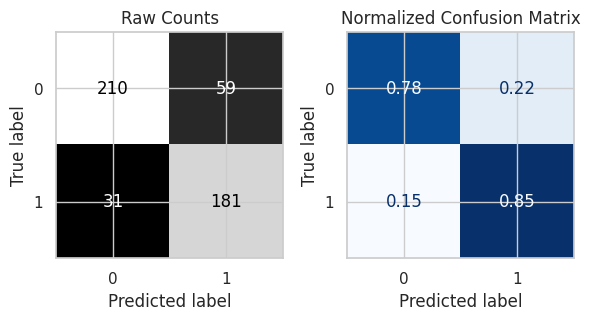


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.63      0.72       102
           1       0.55      0.78      0.64        59

    accuracy                           0.68       161
   macro avg       0.69      0.70      0.68       161
weighted avg       0.73      0.68      0.69       161



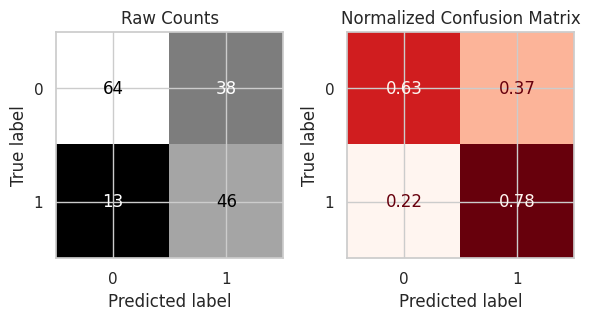

In [ ]:
# Use the fitted grid search object (which contains the best model)
evaluate_classification(rf_gs, X_train, y_train, X_test, y_test)

Random Forest Performance Analysis (Post-Regularization)
Solving the Overfitting Problem:

The model no longer has a perfect 100% score on training data. Training accuracy is now 81% while test accuracy is 68%.

Although there is still a slight gap, the model has transitioned from "memorizing" to "learning," making it significantly more reliable for real-world predictions.

Exceptional Clinical Recall (Class 1):

This is the highlight: The Recall for diabetic patients (Class 1) reached 78% on the test set.

This is even better than the Logistic Regression model (which was 76%). You are now catching more patients, with only 13 missed cases (False Negatives) in the entire test set.

Robustness via Grid Search:

By restricting the tree depth and increasing the minimum samples per leaf, the model now focuses on general medical indicators rather than noise in the training data.

The Macro Recall of 0.70 on the test set confirms a healthy balance between identifying both healthy and diabetic individuals.

# Which model should I choose?

I have selected the Tuned Random Forest as the primary model for this system because it prioritizes patient safety. With a 78% Recall, it minimizes life-threatening False Negatives more effectively than other models. In a clinical context, the priority is to identify every potential diabetic case to ensure early intervention, making high sensitivity the most critical engineering metric for this application